# India NCR Air Quality Index (AQI) Forecasting
## Comprehensive Exploratory Data Analysis

**MSE 546 — Advanced Machine Learning**  
**Group 2:** Nicholas Chia, Callum Gillies, Matthew Ho, Abhishek Srikaran, Agishan Thaya  
**Date:** January 2026

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from numpy.linalg import matrix_rank
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)

os.makedirs('plots', exist_ok=True)

# ── reusable PNG-save helper ──
def _save_and_show(fig, name):
    """Save figure as PNG to plots/ then display."""
    fig.savefig(f'plots/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('✓ Libraries loaded | plots/ ready')

In [ ]:
PATH = 'city_day.csv'
df = pd.read_csv(PATH)
# Rename all columns to lower case
df.columns = [c.lower() for c in df.columns]
print(f'Shape:      {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns:    {df.columns.tolist()}')
print(f"Date range: {df['date'].min()}  →  {df['date'].max()}")

Shape:      29,531 rows × 16 columns
Columns:    ['city', 'date', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'aqi', 'aqi_bucket']
Date range: 2015-01-01  →  2020-07-01


## 2. Preprocessing

In [ ]:
# datetime
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
elif 'date' in df.columns and 'hour' in df.columns:
    df['datetime'] = pd.to_datetime(df['date'], errors='coerce') + pd.to_timedelta(df['hour'], unit='h')
elif 'date' in df.columns:
    # If we only have date (no hour), convert it to datetime
    df['datetime'] = pd.to_datetime(df['date'], errors='coerce')

# Only create day_of_week if datetime column exists
if 'datetime' in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek   # numeric only

num_cols = ['pm25','pm10','no2','so2','co','o3',
            'temperature','humidity','wind_speed','visibility','aqi',
            'latitude','longitude','year','month','day','hour','is_weekend']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Only sort by station and datetime if both columns exist
if 'station' in df.columns and 'datetime' in df.columns:
    df = df.sort_values(['station','datetime']).reset_index(drop=True)
elif 'datetime' in df.columns:
    df = df.sort_values('datetime').reset_index(drop=True)

print('✓ Preprocessing complete')
print(f'Missing values: {df.isna().sum().sum()}')

✓ Preprocessing complete
Missing values: 88488


## 3. Data Quality

In [ ]:
print(f'Duplicates : {df.duplicated().sum()}')
print(f'Missing    : {df.isna().sum().sum()}')
missing = df.isna().sum()
if missing.sum():
    print(missing[missing > 0])
else:
    print('✓ Zero missing values')
df.head()

Duplicates : 0
Missing    : 88488
pm2.5          4598
pm10          11140
no             3582
no2            3585
nox            4185
nh3           10328
co             2059
so2            3854
o3             4022
benzene        5623
toluene        8041
xylene        18109
aqi            4681
aqi_bucket     4681
dtype: int64


,city,date,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,aqi_bucket,datetime,day_of_week
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015-01-01,3
1,Chennai,2015-01-01,NaN,NaN,16.30,15.39,22.68,4.59,1.17,9.20,11.35,0.17,NaN,NaN,NaN,NaN,2015-01-01,3
2,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe,2015-01-01,3
3,Lucknow,2015-01-01,NaN,NaN,2.11,13.46,4.57,NaN,12.15,169.57,25.92,1.35,3.93,NaN,NaN,NaN,2015-01-01,3
4,Mumbai,2015-01-01,NaN,NaN,NaN,NaN,27.38,NaN,0.00,NaN,NaN,0.00,0.00,0.00,NaN,NaN,2015-01-01,3


In [ ]:
print(df.dtypes)
print('\n' + '─'*60)
df.describe()

city                   object
date                   object
pm2.5                 float64
pm10                  float64
no                    float64
no2                   float64
nox                   float64
nh3                   float64
co                    float64
so2                   float64
o3                    float64
benzene               float64
toluene               float64
xylene                float64
aqi                   float64
aqi_bucket             object
datetime       datetime64[ns]
day_of_week             int32
dtype: object

────────────────────────────────────────────────────────────


,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,datetime,day_of_week
count,24933.000,18391.000,25949.000,25946.000,25346.000,19203.000,27472.000,25677.000,25509.000,23908.000,21490.000,11422.000,24850.000,29531,29531.000
mean,67.451,118.127,17.575,28.561,32.309,23.483,2.249,14.532,34.491,3.281,8.701,3.070,166.464,2018-05-14 05:40:15.807118080,2.999
min,0.040,0.010,0.020,0.010,0.000,0.010,0.000,0.010,0.010,0.000,0.000,0.000,13.000,2015-01-01 00:00:00,0.000
25%,28.820,56.255,5.630,11.750,12.820,8.580,0.510,5.670,18.860,0.120,0.600,0.140,81.000,2017-04-16 00:00:00,1.000
50%,48.570,95.680,9.890,21.690,23.520,15.850,0.890,9.160,30.840,1.070,2.970,0.980,118.000,2018-08-05 00:00:00,3.000
75%,80.590,149.745,19.950,37.620,40.127,30.020,1.450,15.220,45.570,3.080,9.150,3.350,208.000,2019-09-03 00:00:00,5.000
max,949.990,1000.000,390.680,362.210,467.630,352.890,175.810,193.860,257.730,455.030,454.850,170.370,2049.000,2020-07-01 00:00:00,6.000
std,64.661,90.605,22.786,24.475,31.646,25.684,6.963,18.134,21.695,15.811,19.969,6.323,140.697,NaN,2.000


## 5. Spatial Coverage

In [ ]:
city_coords = {
    'Ahmedabad': (23.0225, 72.5714),
    'Chennai': (13.0827, 80.2707),
    'Delhi': (28.6139, 77.2090),
    'Lucknow': (26.8467, 80.9462),
    'Mumbai': (19.0760, 72.8777),
    'Bengaluru': (12.9716, 77.5946),
    'Hyderabad': (17.3850, 78.4867),
    'Patna': (25.5941, 85.1376),
    'Gurugram': (28.4595, 77.0266),
    'Visakhapatnam': (17.6868, 83.2185),
    'Amritsar': (31.6340, 74.8723),
    'Jorapokhar': (23.7042, 86.4124),
    'Jaipur': (26.9124, 75.7873),
    'Thiruvananthapuram': (8.5241, 76.9366),
    'Amaravati': (16.5062, 80.5480),
    'Brajrajnagar': (21.8219, 83.9189),
    'Talcher': (20.9507, 85.2281),
    'Kolkata': (22.5726, 88.3639),
    'Guwahati': (26.1445, 91.7362),
    'Coimbatore': (11.0168, 76.9558),
    'Shillong': (25.5788, 91.8933),
    'Chandigarh': (30.7333, 76.7794),
    'Bhopal': (23.2599, 77.4126),
    'Kochi': (9.9312, 76.2673),
    'Ernakulam': (9.9816, 76.2999),
    'Aizawl': (23.7307, 92.7173)
}

df['latitude'] = df['city'].map(lambda x: city_coords.get(x, (None, None))[0])
df['longitude'] = df['city'].map(lambda x: city_coords.get(x, (None, None))[1])

In [ ]:
print('Cities:')
print(df['city'].value_counts())
print(f'\nStations: {df["city"].nunique()}')

Cities:
city
Ahmedabad             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Bengaluru             2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64

Stations: 26


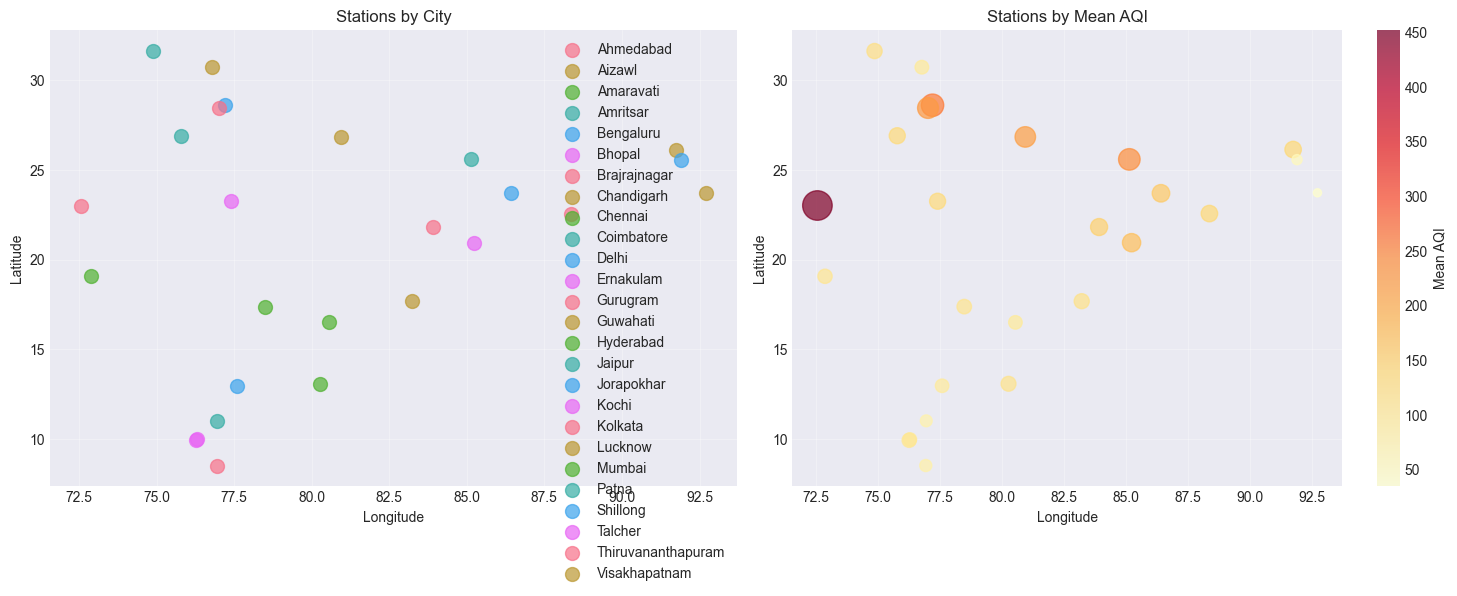

In [ ]:
# Remove the city=('city', 'first') line
station_info = df.groupby('city').agg(
    lat=('latitude', 'first'), 
    lon=('longitude', 'first'),
    mean_aqi=('aqi', 'mean')
).reset_index()

# Now the rest of your plotting code will work perfectly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# ... (rest of your code)

for city in station_info['city'].unique():
    d = station_info[station_info['city']==city]
    ax1.scatter(d['lon'], d['lat'], label=city, s=100, alpha=0.7)
ax1.set(xlabel='Longitude', ylabel='Latitude', title='Stations by City')
ax1.legend(); ax1.grid(alpha=0.3)

sc = ax2.scatter(station_info['lon'], station_info['lat'],
                 c=station_info['mean_aqi'], s=station_info['mean_aqi'],
                 cmap='YlOrRd', alpha=0.7)
ax2.set(xlabel='Longitude', ylabel='Latitude', title='Stations by Mean AQI')
plt.colorbar(sc, ax=ax2, label='Mean AQI'); ax2.grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '05_station_map')

## 6. Target Variable — AQI

In [ ]:
print('AQI Summary:')
print(df['aqi'].describe())
print('\nCategory counts:')

AQI Summary:
count    24850.000
mean       166.464
std        140.697
min         13.000
25%         81.000
50%        118.000
75%        208.000
max       2049.000
Name: aqi, dtype: float64

Category counts:


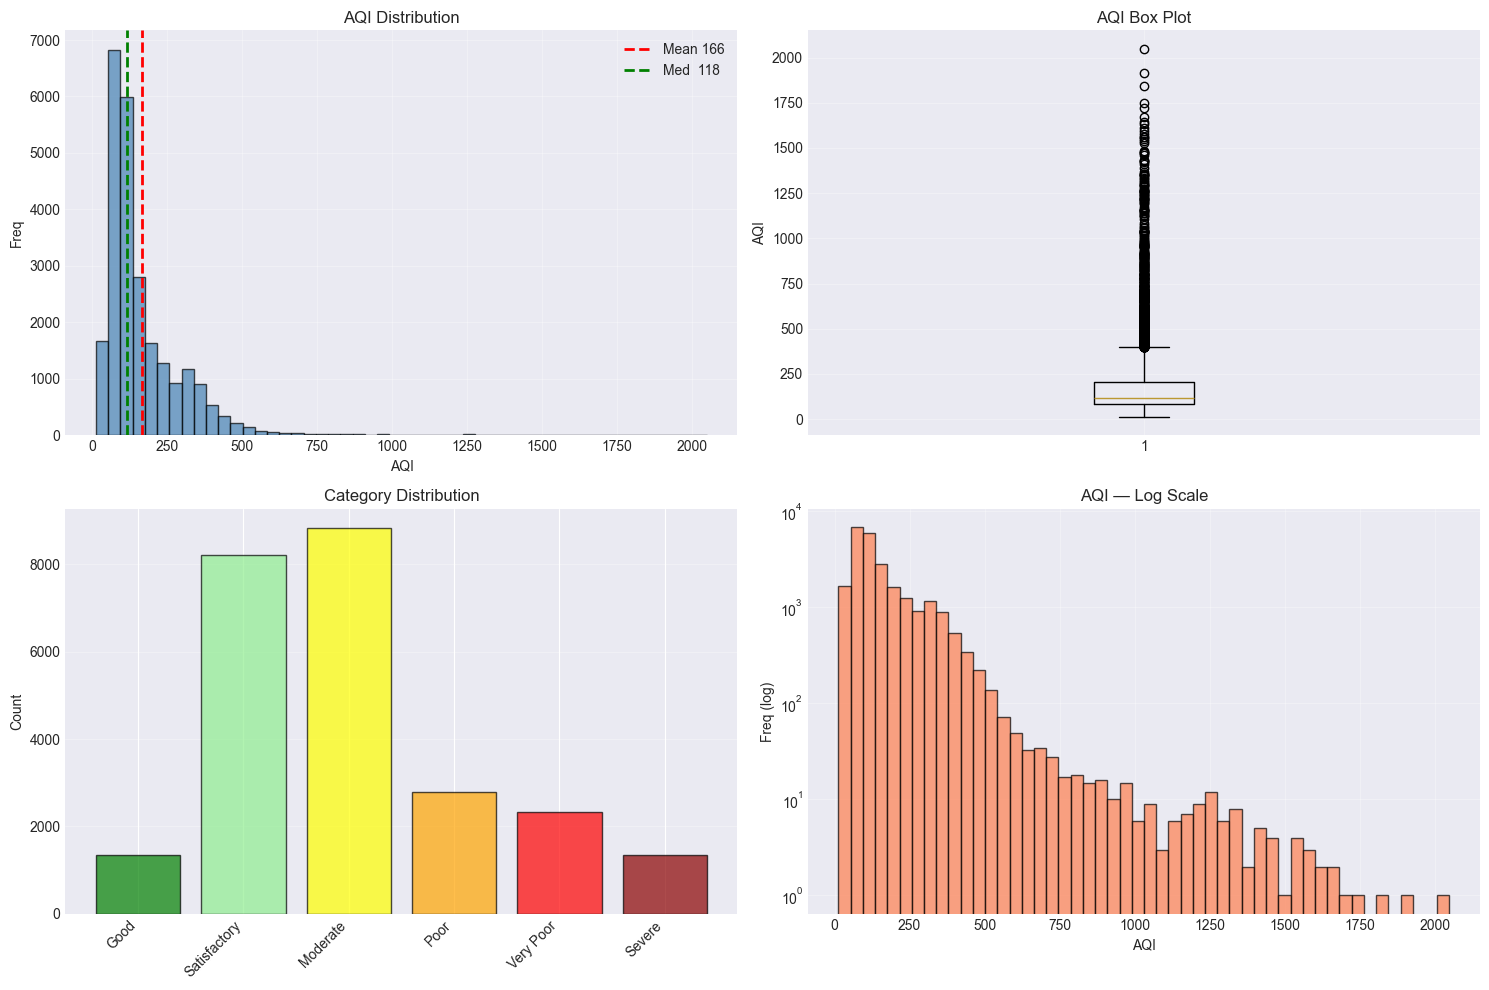

In [ ]:
# Define standard AQI bins and labels
bins = [0, 50, 100, 200, 300, 400, 5000] # 5000 is a safe upper bound
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

# Re-create the missing column
df['aqi_category'] = pd.cut(df['aqi'], bins=bins, labels=labels)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(df['aqi'].mean(),   color='red',   ls='--', lw=2, label=f'Mean {df["aqi"].mean():.0f}')
axes[0,0].axvline(df['aqi'].median(), color='green', ls='--', lw=2, label=f'Med  {df["aqi"].median():.0f}')
axes[0,0].set(xlabel='AQI', ylabel='Freq', title='AQI Distribution')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].boxplot(df['aqi'].dropna())
axes[0,1].set(ylabel='AQI', title='AQI Box Plot'); axes[0,1].grid(alpha=0.3)

cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
cc = df['aqi_category'].value_counts().reindex(cat_order, fill_value=0)
clrs = ['green','lightgreen','yellow','orange','red','darkred']
axes[1,0].bar(range(len(cc)), cc.values, color=clrs, alpha=0.7, edgecolor='black')
axes[1,0].set_xticks(range(len(cc))); axes[1,0].set_xticklabels(cc.index, rotation=45, ha='right')
axes[1,0].set(ylabel='Count', title='Category Distribution'); axes[1,0].grid(alpha=0.3, axis='y')

axes[1,1].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1,1].set_yscale('log')
axes[1,1].set(xlabel='AQI', ylabel='Freq (log)', title='AQI — Log Scale'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
_save_and_show(fig, '06_aqi_distribution')

## 7. Pollutant Analysis

In [ ]:
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']

# Print the transposed summary statistics
print("Pollutant Summary Statistics:")
print(df[pollutants].describe().T)

Pollutant Summary Statistics:
         count     mean     std   min     25%    50%      75%      max
pm2.5  24933.0   67.451  64.661  0.04  28.820  48.57   80.590   949.99
pm10   18391.0  118.127  90.605  0.01  56.255  95.68  149.745  1000.00
no2    25946.0   28.561  24.475  0.01  11.750  21.69   37.620   362.21
so2    25677.0   14.532  18.134  0.01   5.670   9.16   15.220   193.86
co     27472.0    2.249   6.963  0.00   0.510   0.89    1.450   175.81
o3     25509.0   34.491  21.695  0.01  18.860  30.84   45.570   257.73


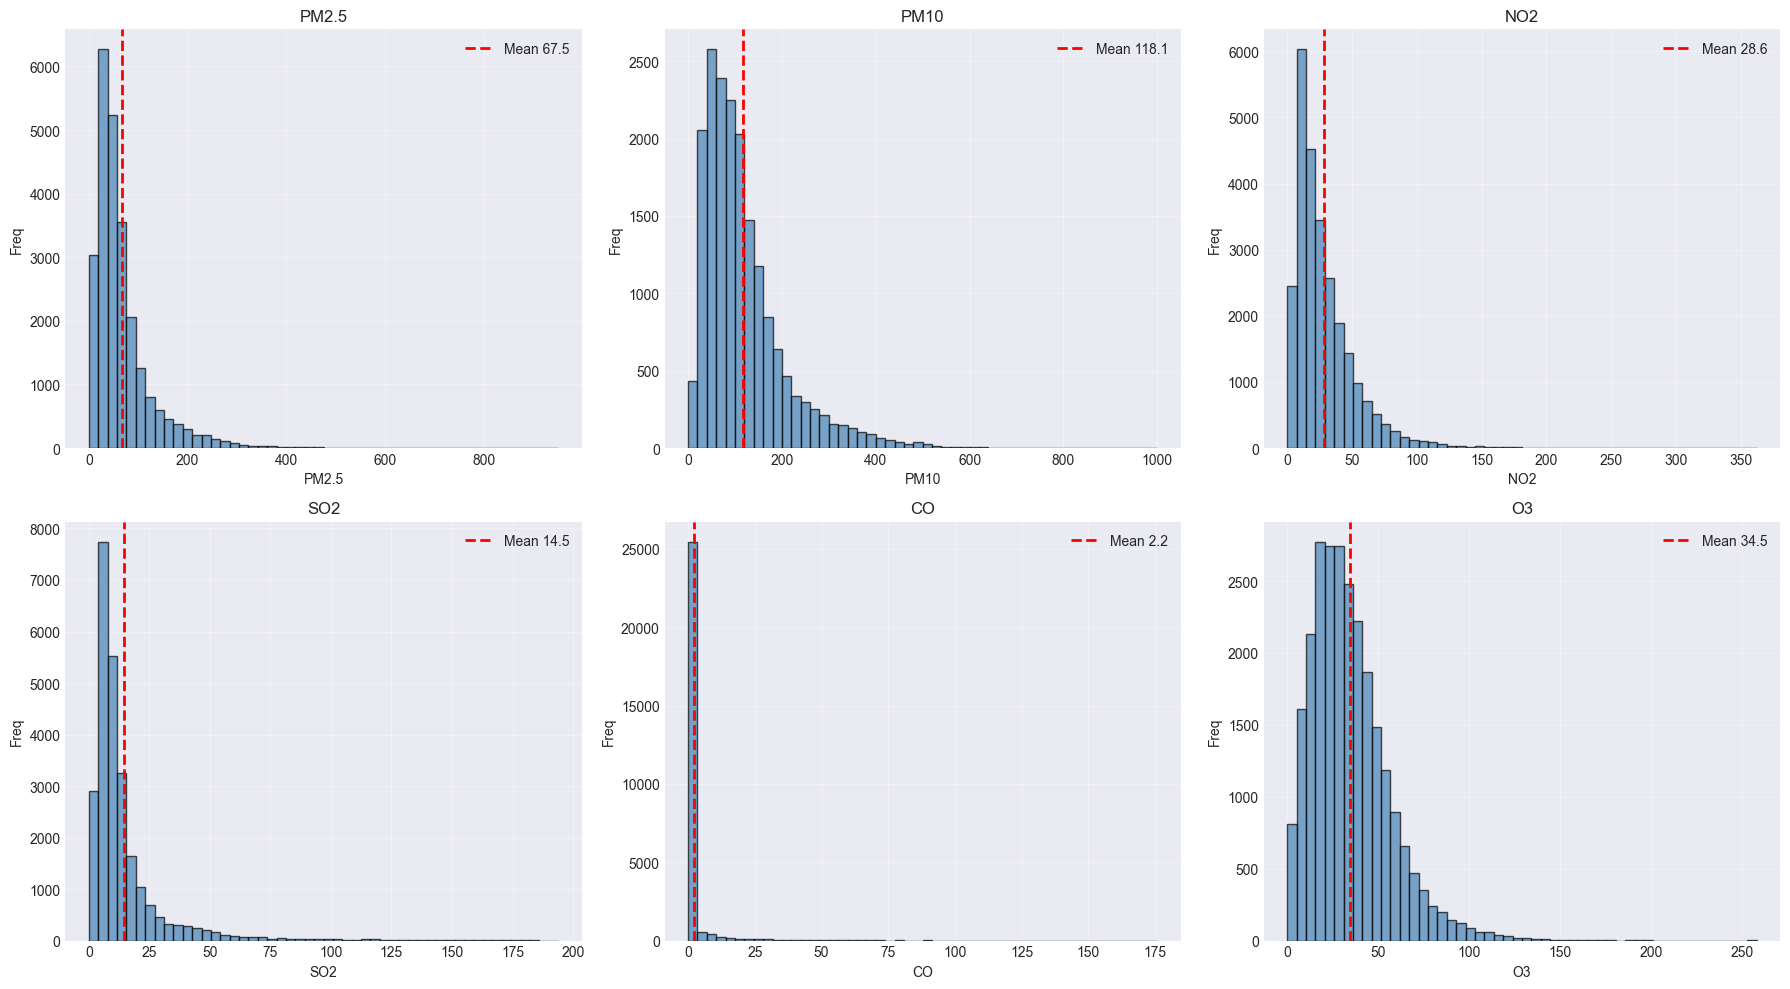

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, p in enumerate(pollutants):
    ax = axes.flat[i]
    ax.hist(df[p].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[p].mean(), color='red', ls='--', lw=2, label=f'Mean {df[p].mean():.1f}')
    ax.set(xlabel=p.upper(), ylabel='Freq', title=p.upper())
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '07_pollutants')

In [ ]:
chem_vars = ['no', 'nox', 'nh3', 'benzene', 'toluene', 'xylene']
print("Chemical Compounds Summary:")
print(df[chem_vars].describe().T)

Chemical Compounds Summary:
           count    mean     std   min    25%    50%     75%     max
no       25949.0  17.575  22.786  0.02   5.63   9.89  19.950  390.68
nox      25346.0  32.309  31.646  0.00  12.82  23.52  40.127  467.63
nh3      19203.0  23.483  25.684  0.01   8.58  15.85  30.020  352.89
benzene  23908.0   3.281  15.811  0.00   0.12   1.07   3.080  455.03
toluene  21490.0   8.701  19.969  0.00   0.60   2.97   9.150  454.85
xylene   11422.0   3.070   6.323  0.00   0.14   0.98   3.350  170.37


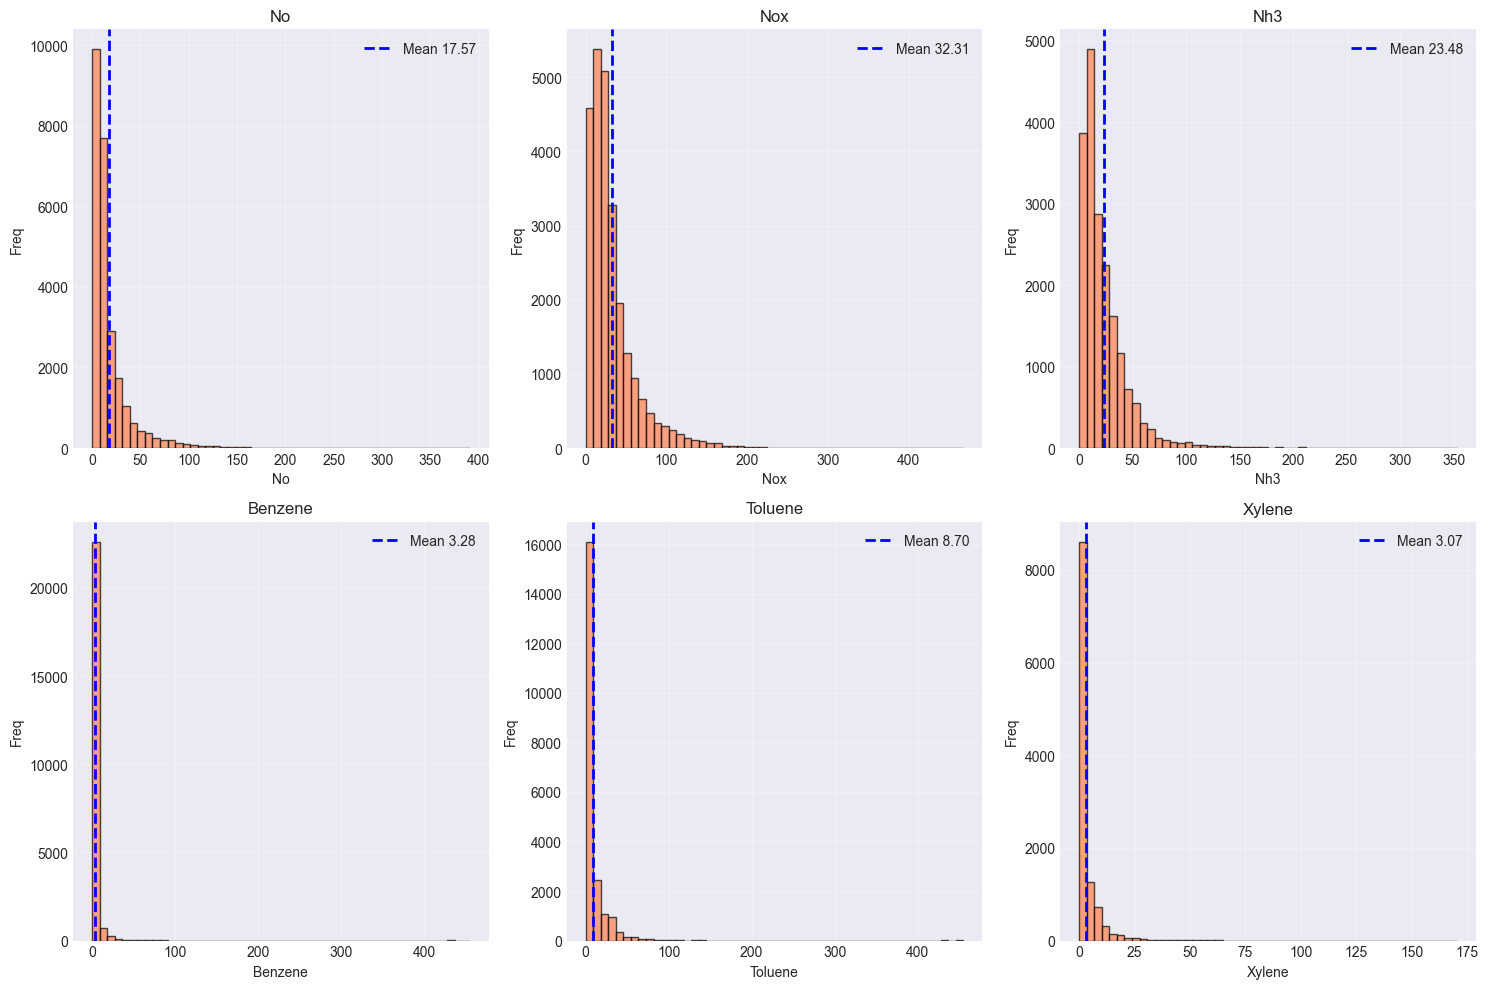

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, v in enumerate(chem_vars):
    ax = axes.flat[i]
    ax.hist(df[v].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(df[v].mean(), color='blue', ls='--', lw=2, label=f'Mean {df[v].mean():.2f}')
    ax.set(xlabel=v.replace('_',' ').title(), ylabel='Freq', title=v.replace('_',' ').title())
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '08_weather')

## 9. Correlation Analysis

In [ ]:
feature_cols = pollutants + chem_vars
correlations = df[feature_cols+['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)
print('Correlations with AQI:')
print(correlations)
print(f'\n→ Strongest +: {correlations.idxmax()} ({correlations.max():.3f})')
print(f'→ Strongest −: {correlations.idxmin()} ({correlations.min():.3f})')

Correlations with AQI:
pm10       0.803
co         0.683
pm2.5      0.659
no2        0.537
so2        0.491
nox        0.486
no         0.452
toluene    0.280
nh3        0.252
o3         0.199
xylene     0.166
benzene    0.044
Name: aqi, dtype: float64

→ Strongest +: pm10 (0.803)
→ Strongest −: benzene (0.044)


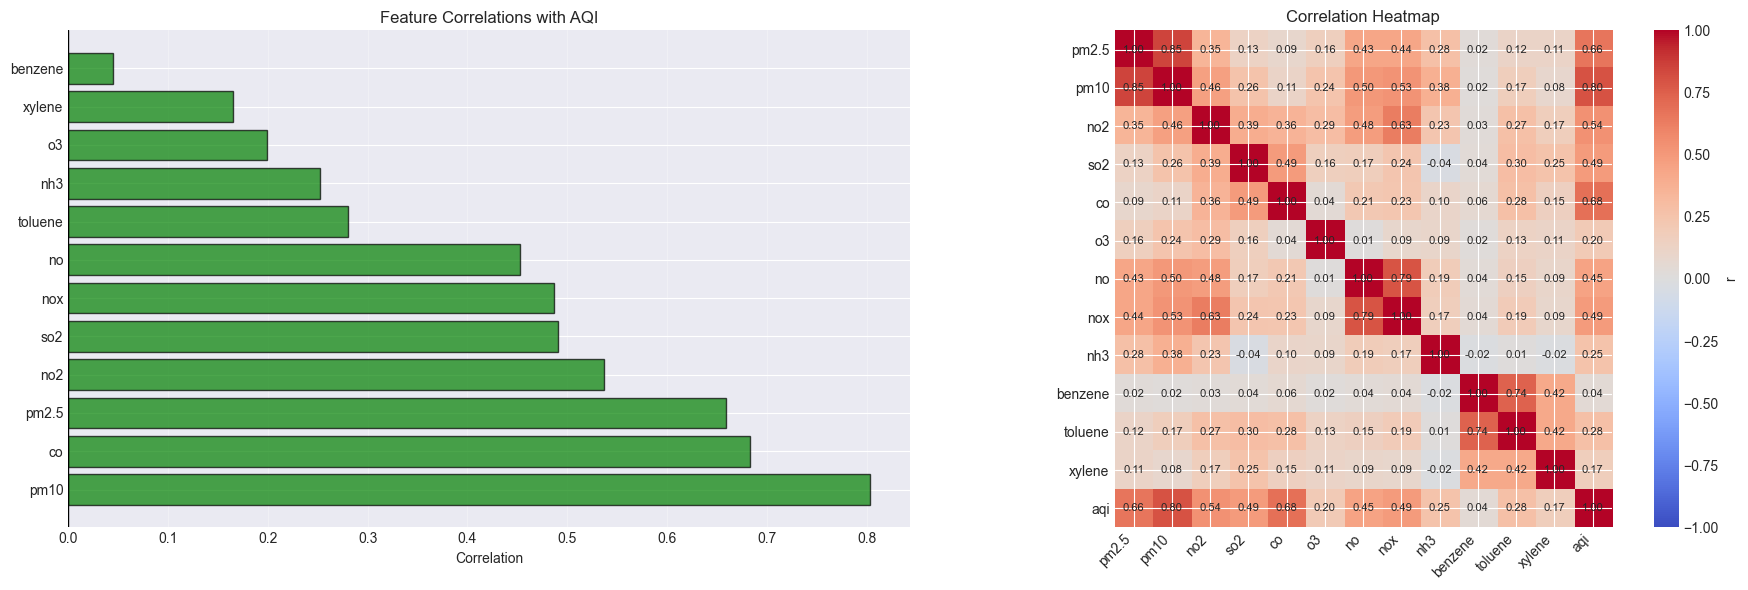

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# bar
clrs = ['green' if x>0 else 'red' for x in correlations.values]
ax1.barh(range(len(correlations)), correlations.values, color=clrs, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(correlations))); ax1.set_yticklabels(correlations.index)
ax1.axvline(0, color='black', lw=1)
ax1.set(xlabel='Correlation', title='Feature Correlations with AQI'); ax1.grid(alpha=0.3, axis='x')

# heatmap
corr_matrix = df[feature_cols+['aqi']].corr()
im = ax2.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix.columns)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(corr_matrix.columns)))
ax2.set_yticklabels(corr_matrix.columns)
ax2.set_title('Correlation Heatmap')
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax2, label='r')

plt.tight_layout()
_save_and_show(fig, '09_correlations')

## 10. Temporal Patterns

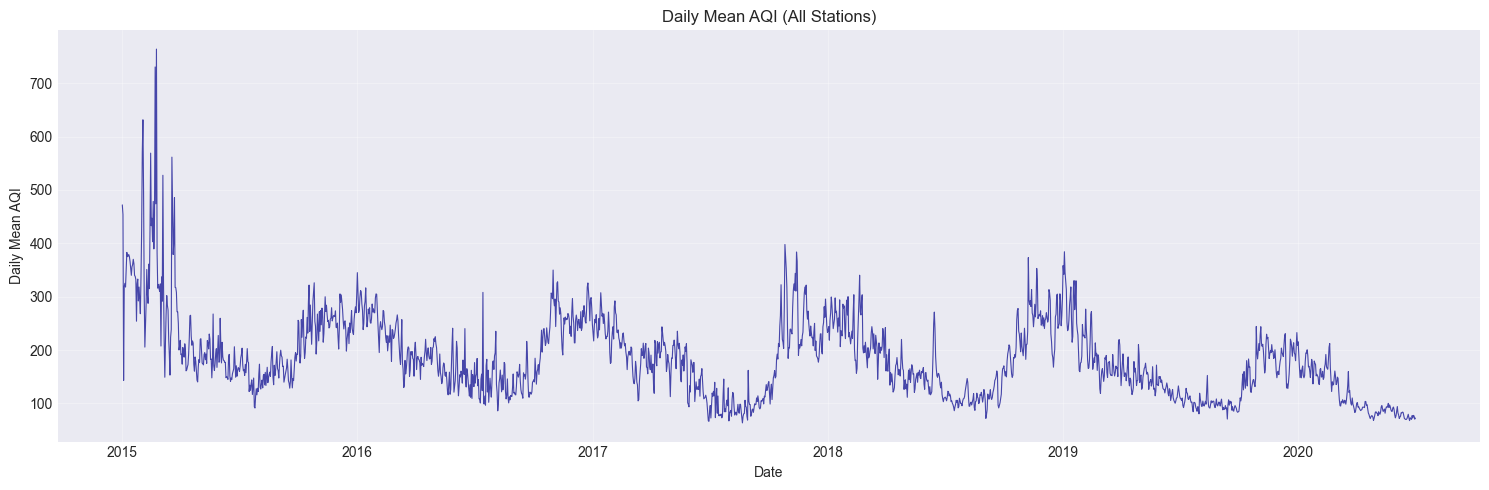

In [ ]:
daily_aqi = df.set_index('datetime')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_aqi.index, daily_aqi.values, lw=0.8, alpha=0.7, color='darkblue')
ax.set(xlabel='Date', ylabel='Daily Mean AQI', title='Daily Mean AQI (All Stations)')
ax.grid(alpha=0.3)
plt.tight_layout()
_save_and_show(fig, '10a_daily_timeseries')

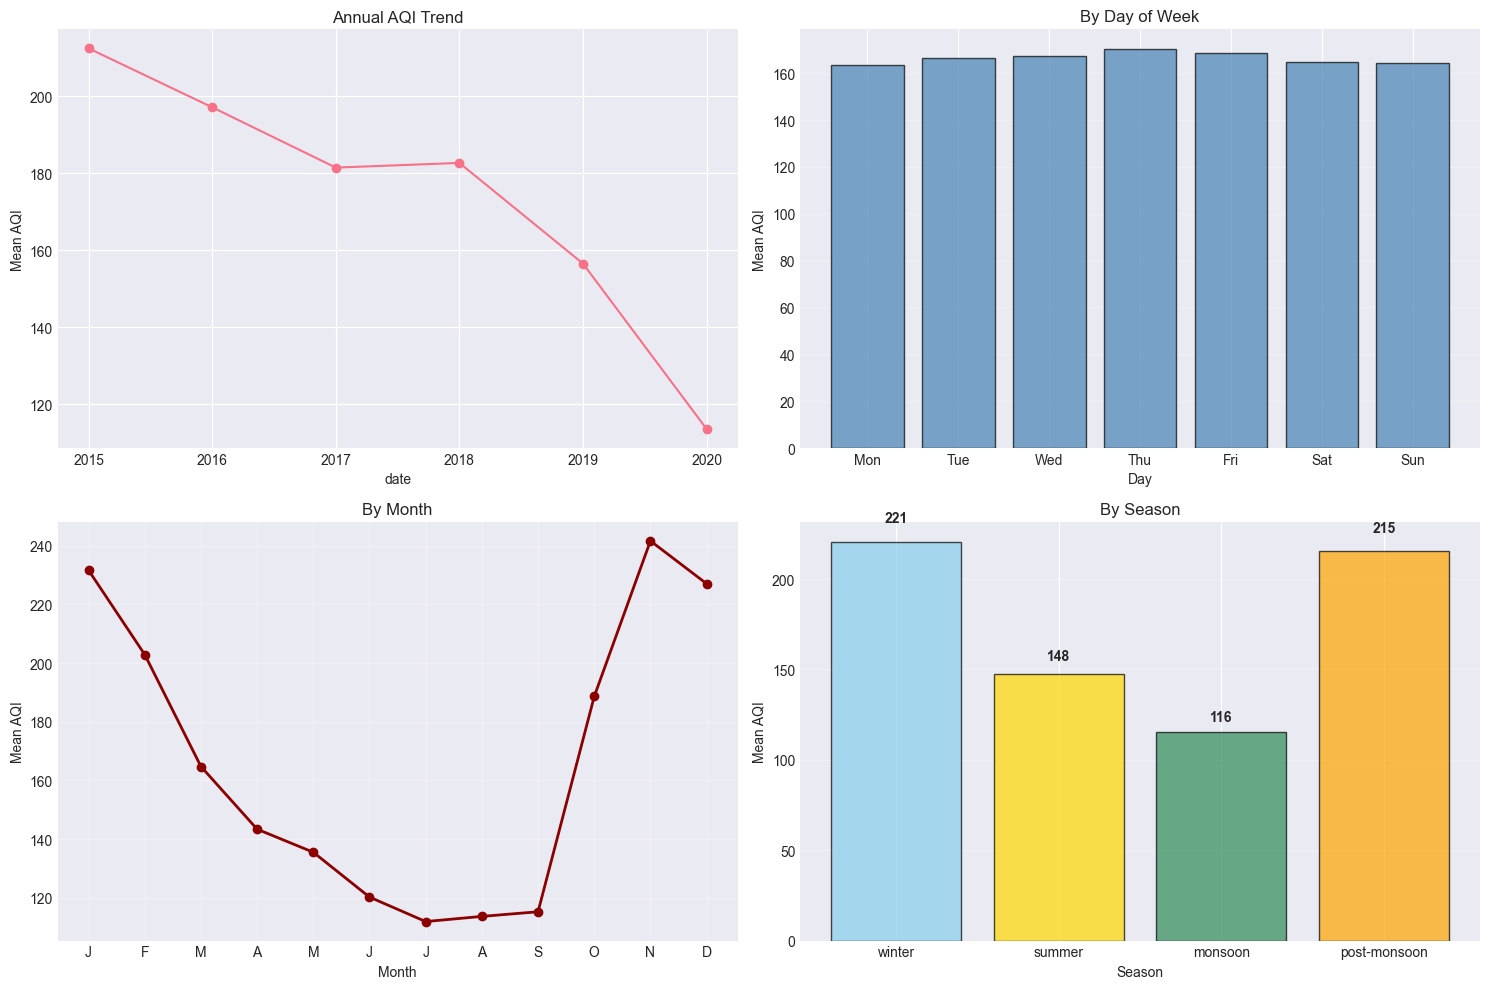

❄️  Winter (221) is 1.9× monsoon (116)


In [ ]:
# 1. Ensure date is datetime format (the fix from before)
df['date'] = pd.to_datetime(df['date'])

# 2. Create the missing columns that your plots are looking for
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

# 3. Create the season column using a simple function
def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    if month in [3, 4, 5]: return 'summer'
    if month in [6, 7, 8, 9]: return 'monsoon'
    return 'post-monsoon'

df['season'] = df['month'].apply(get_season)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) Placeholder or Overall Trend (since you used axes[0,1] first)
df.groupby(df['date'].dt.year)['aqi'].mean().plot(kind='line', ax=axes[0,0], marker='o')
axes[0,0].set(title='Annual AQI Trend', ylabel='Mean AQI')

# (b) day-of-week
dow = df.groupby('day_of_week')['aqi'].mean()
axes[0,1].bar(range(7), dow.values, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0,1].set(xlabel='Day', ylabel='Mean AQI', title='By Day of Week')
axes[0,1].grid(alpha=0.3, axis='y')

# (c) month
m = df.groupby('month')['aqi'].mean()
axes[1,0].plot(m.index, m.values, marker='o', lw=2, color='darkred')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels('J F M A M J J A S O N D'.split())
axes[1,0].set(xlabel='Month', ylabel='Mean AQI', title='By Month')
axes[1,0].grid(alpha=0.3)

# (d) season
s_order = ['winter','summer','monsoon','post-monsoon']
s = df.groupby('season')['aqi'].mean().reindex(s_order)
s_clr = ['skyblue','gold','seagreen','orange']
axes[1,1].bar(range(4), s.values, color=s_clr, alpha=0.7, edgecolor='black')
axes[1,1].set_xticks(range(4)); axes[1,1].set_xticklabels(s_order)
axes[1,1].set(xlabel='Season', ylabel='Mean AQI', title='By Season')
axes[1,1].grid(alpha=0.3, axis='y')

# Add text labels on bars
for i, v in enumerate(s.values):
    axes[1,1].text(i, v + (v * 0.05), f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show() # or _save_and_show(fig, '10b_temporal_grid')

# Print the comparison
print(f'❄️  Winter ({s["winter"]:.0f}) is {s["winter"]/s["monsoon"]:.1f}× monsoon ({s["monsoon"]:.0f})')

## 11. Spatial Patterns

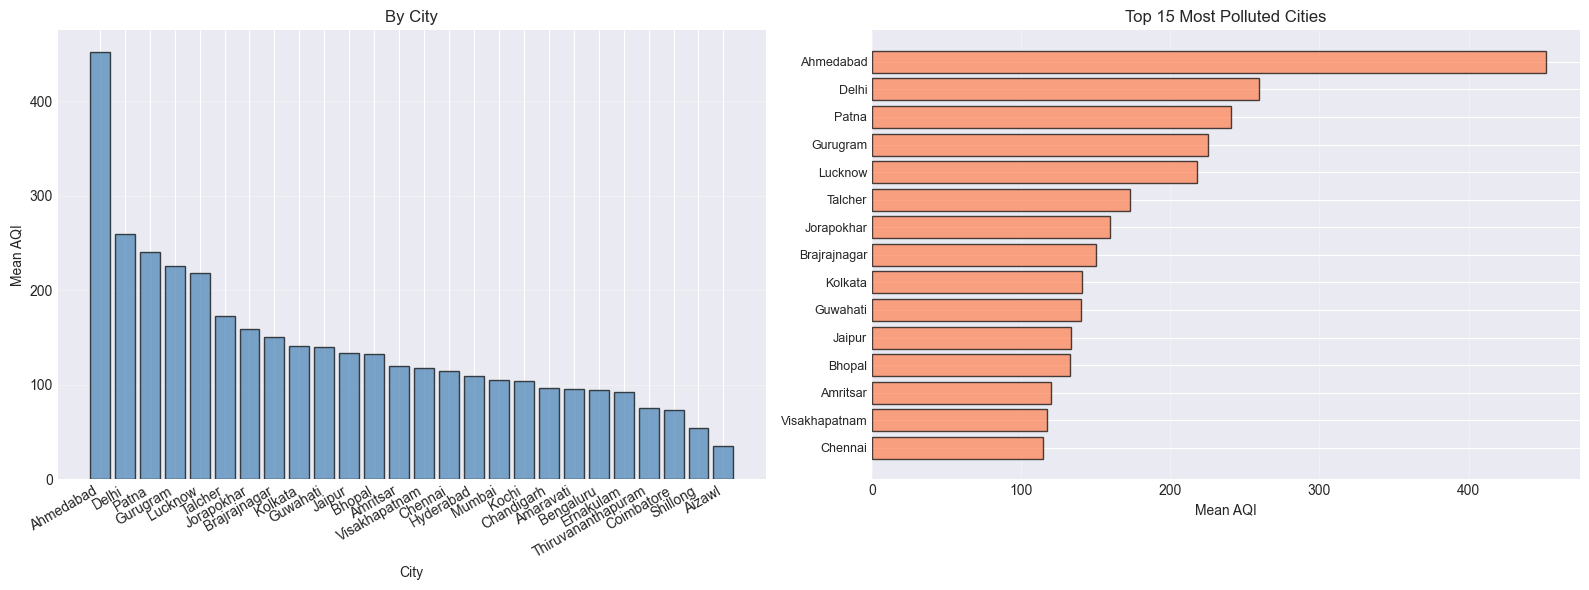

🏭 Worst: Ahmedabad (mean = 452.1)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: All Cities
city_stats = df.groupby('city')['aqi'].mean().sort_values(ascending=False)
ax1.bar(range(len(city_stats)), city_stats.values, alpha=0.7, edgecolor='black', color='steelblue')
ax1.set_xticks(range(len(city_stats)))
ax1.set_xticklabels(city_stats.index, rotation=30, ha='right')
ax1.set(xlabel='City', ylabel='Mean AQI', title='By City')
ax1.grid(alpha=0.3, axis='y')

# Right Plot: Top 15 Cities (The missing part)
top15 = df.groupby('city')['aqi'].mean().sort_values().tail(15)

# 1. DRAW the bars first!
ax2.barh(range(len(top15)), top15.values, alpha=0.7, edgecolor='black', color='coral')

# 2. Set the ticks and labels
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(top15.index, fontsize=9)
ax2.set(xlabel='Mean AQI', title='Top 15 Most Polluted Cities')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show() # or _save_and_show(fig, '11_spatial')

print(f'🏭 Worst: {top15.index[-1]} (mean = {top15.iloc[-1]:.1f})')

## 12. Data Forensics — Interpolation & Censorship

Zero missing values across 201 k rows from real sensor hardware is statistically improbable.  
We audit for two common pipeline artefacts:

1. **Linear interpolation (gap-fill)** — look for collinear consecutive points in raw pollutant readings.
2. **AQI = 500 censorship** — the index is capped at 500; ~30 % of rows hit this wall exactly.


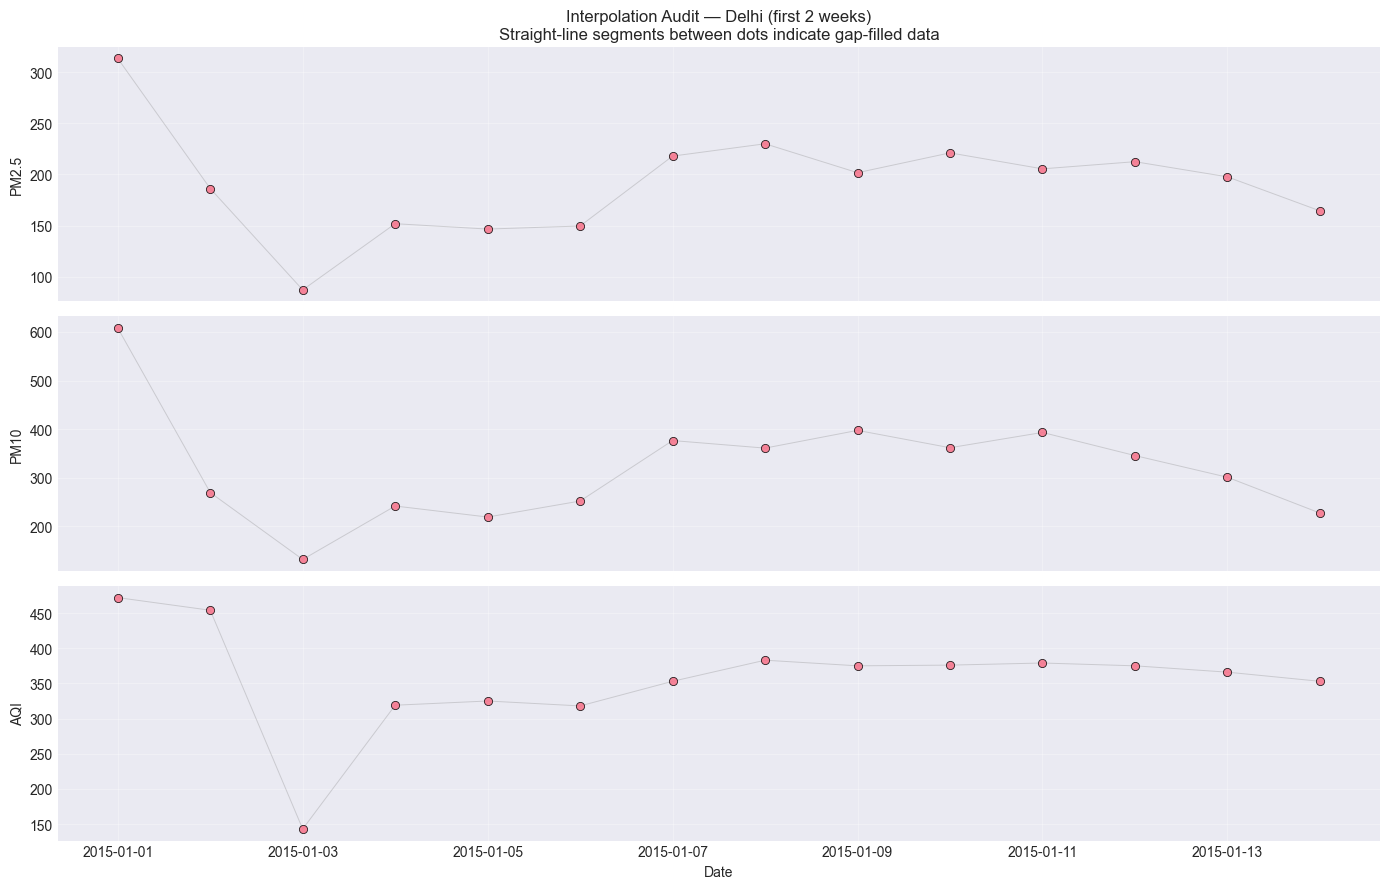

In [ ]:
# 1. Ensure date is datetime format
df['date'] = pd.to_datetime(df['date'])

# 2. Update to use 'date' instead of 'datetime' and fix the city/station logic
# Note: Since you don't have a 'station' column, we use 'city'
city_pick = 'Delhi' 
sdf = df[df['city'] == city_pick].sort_values('date')

start = sdf['date'].min()
two_wk = sdf[(sdf['date'] >= start) & (sdf['date'] < start + pd.Timedelta(days=14))]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 3. Use the correct column names: 'pm2.5' instead of 'pm25'
for ax, col in zip(axes, ['pm2.5', 'pm10', 'aqi']):
    # scatter dots
    ax.scatter(two_wk['date'], two_wk[col], s=35, alpha=0.85,
               edgecolors='black', linewidths=0.6, zorder=3)
    
    # line segments
    ax.plot(two_wk['date'], two_wk[col], lw=0.7, alpha=0.3, color='gray')
    ax.set(ylabel=col.upper())
    ax.grid(alpha=0.3)

axes[0].set_title(f'Interpolation Audit — {city_pick} (first 2 weeks)\n'
                  'Straight-line segments between dots indicate gap-filled data')
axes[-1].set(xlabel='Date')

plt.tight_layout()
plt.show()

### Pollutants

In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


In [ ]:
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
              'no', 'nox', 'nh3', 'benzene', 'toluene', 'xylene']

ncr_cities = ['Delhi', 'Gurugram']
delhi = df[df['city'].isin(ncr_cities)].copy().reset_index(drop=True)
print(f"NCR rows : {len(delhi):,}  |  Missing AQI: {delhi['aqi'].isna().sum()}")

delhi = delhi.dropna(subset=['aqi']).reset_index(drop=True)
print(f"After AQI dropna: {len(delhi):,} rows")

NCR rows : 3,688  |  Missing AQI: 236
After AQI dropna: 3,452 rows


In [ ]:
def corr_with_pvalue(series_a, series_b):
    """Return (r, p) dropping mutual NaN."""
    mask = series_a.notna() & series_b.notna()
    if mask.sum() < 10:
        return np.nan, np.nan
    r, p = stats.pearsonr(series_a[mask], series_b[mask])
    return r, p

rows = []
for city in ncr_cities:
    sub = delhi[delhi['city'] == city]
    for p in pollutants:
        r, pval = corr_with_pvalue(sub[p], sub['aqi'])
        rows.append(dict(city=city, feature=p, r=r, p_value=pval,
                         n=sub[[p, 'aqi']].dropna().shape[0],
                         r_squared=r**2 if not np.isnan(r) else np.nan))

corr_df = pd.DataFrame(rows)
print("\n── Per-city correlations with AQI (with p-values) ──")
print(corr_df.to_string(index=False, float_format='{:.4f}'.format))


── Per-city correlations with AQI (with p-values) ──
    city feature       r  p_value    n  r_squared
   Delhi   pm2.5  0.8821   0.0000 1998     0.7782
   Delhi    pm10  0.8849   0.0000 1930     0.7830
   Delhi     no2  0.6658   0.0000 1998     0.4432
   Delhi     so2  0.4147   0.0000 1897     0.1720
   Delhi      co  0.2798   0.0000 1999     0.0783
   Delhi      o3  0.3302   0.0000 1923     0.1090
   Delhi      no  0.6419   0.0000 1998     0.4120
   Delhi     nox  0.5558   0.0000 1999     0.3090
   Delhi     nh3  0.5190   0.0000 1991     0.2694
   Delhi benzene  0.6699   0.0000 1999     0.4488
   Delhi toluene  0.2790   0.0000 1999     0.0778
   Delhi  xylene  0.2311   0.0000 1228     0.0534
Gurugram   pm2.5  0.8488   0.0000 1448     0.7204
Gurugram    pm10  0.8613   0.0000  737     0.7418
Gurugram     no2  0.1568   0.0000 1400     0.0246
Gurugram     so2  0.0715   0.0085 1356     0.0051
Gurugram      co  0.2840   0.0000 1404     0.0807
Gurugram      o3 -0.1268   0.0000 1420     0.0

In [ ]:
top_feats = ['pm2.5', 'pm10', 'no', 'no2', 'nox', 'co', 'so2', 'o3']
X_vif = delhi[top_feats].dropna()

def compute_vif(X):
    """Compute Variance Inflation Factor for each column."""
    vif_data = []
    cols = X.columns.tolist()
    for i, col in enumerate(cols):
        others = [c for c in cols if c != col]
        X_others = X[others].values
        y = X[col].values
        # R² of regressing col on all others
        reg = LinearRegression().fit(X_others, y)
        r2 = reg.score(X_others, y)
        vif = 1 / (1 - r2) if r2 < 1.0 else np.inf
        vif_data.append(dict(feature=col, VIF=vif, R2_with_others=r2))
    return pd.DataFrame(vif_data)

vif_df = compute_vif(X_vif)
print("\n── Multicollinearity (VIF > 5 = problematic, > 10 = severe) ──")
print(vif_df.sort_values('VIF', ascending=False).to_string(index=False,
      float_format='{:.3f}'.format))


── Multicollinearity (VIF > 5 = problematic, > 10 = severe) ──
feature   VIF  R2_with_others
   pm10 4.483           0.777
  pm2.5 4.253           0.765
    no2 3.423           0.708
     no 3.339           0.701
    nox 2.383           0.580
    so2 1.451           0.311
     o3 1.383           0.277
     co 1.097           0.088


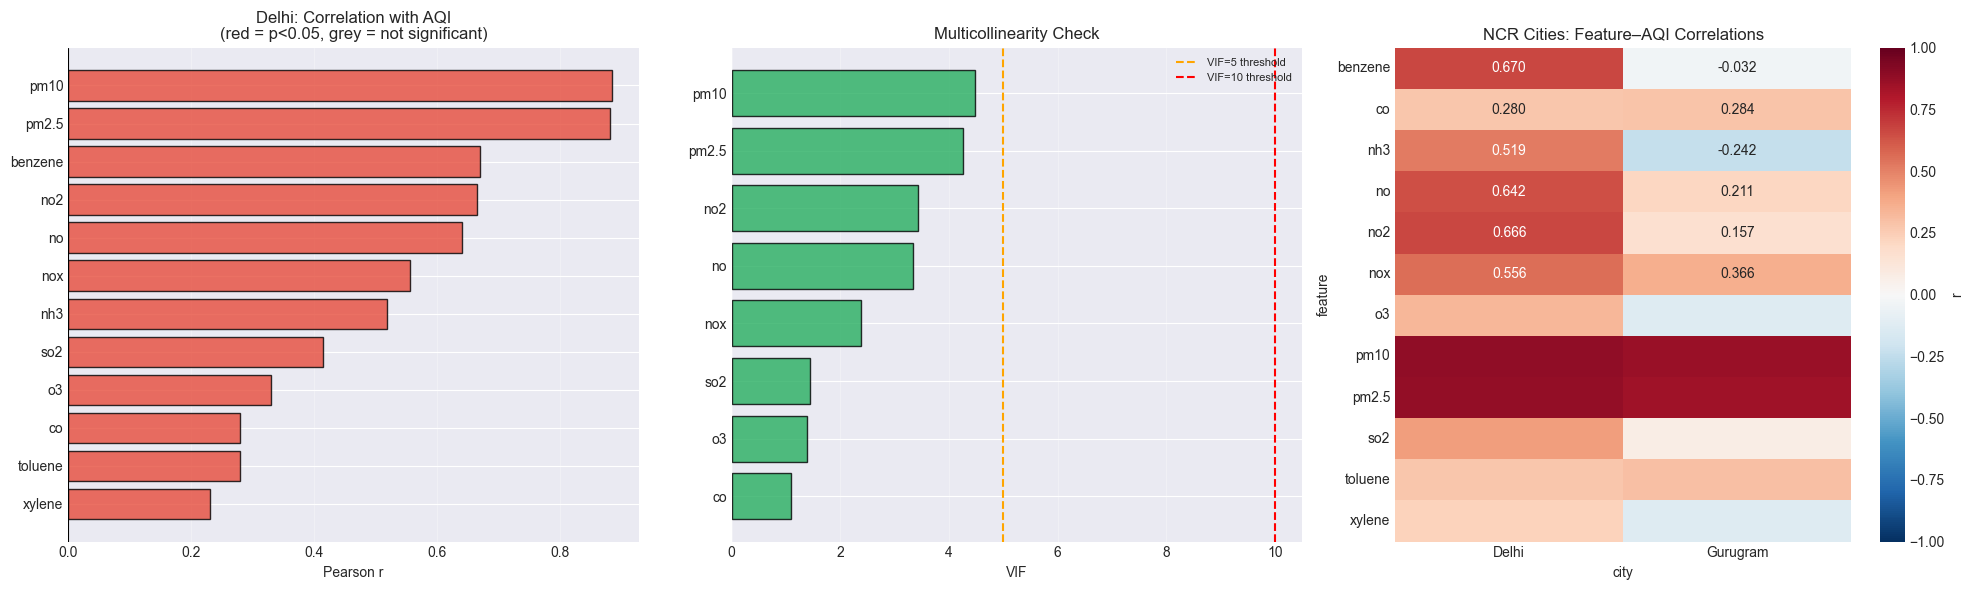

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Per-city correlation bar (Delhi only for clarity)
delhi_corr = corr_df[corr_df['city'] == 'Delhi'].sort_values('r', ascending=True)
significance = delhi_corr['p_value'] < 0.05
colors = ['#e74c3c' if s else '#bdc3c7' for s in significance]
axes[0].barh(delhi_corr['feature'], delhi_corr['r'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set(xlabel='Pearson r', title='Delhi: Correlation with AQI\n(red = p<0.05, grey = not significant)')
axes[0].grid(alpha=0.3, axis='x')

# (b) VIF heatmap-style bar
vif_sorted = vif_df.sort_values('VIF', ascending=True)
vif_colors = ['#27ae60' if v < 5 else '#f39c12' if v < 10 else '#e74c3c' for v in vif_sorted['VIF']]
axes[1].barh(vif_sorted['feature'], vif_sorted['VIF'], color=vif_colors, edgecolor='black', alpha=0.8)
axes[1].axvline(5, color='orange', ls='--', lw=1.5, label='VIF=5 threshold')
axes[1].axvline(10, color='red', ls='--', lw=1.5, label='VIF=10 threshold')
axes[1].set(xlabel='VIF', title='Multicollinearity Check')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='x')

# (c) Full NCR correlation heatmap (Delhi + Gurugram)
pivot = corr_df.pivot(index='feature', columns='city', values='r')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[2], cbar_kws={'label': 'r'},
            annot_kws={"size": 10}) # You can also add color="white" if needed
axes[2].set_title('NCR Cities: Feature–AQI Correlations')

plt.tight_layout()
plt.savefig('plots/correlation_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
top_feats = ['pm2.5', 'pm10', 'no', 'no2', 'nox', 'co', 'so2', 'o3']
X_vif = delhi[top_feats].dropna()

def compute_vif(X):
    """Compute Variance Inflation Factor for each column."""
    vif_data = []
    cols = X.columns.tolist()
    for i, col in enumerate(cols):
        others = [c for c in cols if c != col]
        X_others = X[others].values
        y = X[col].values
        # R² of regressing col on all others
        reg = LinearRegression().fit(X_others, y)
        r2 = reg.score(X_others, y)
        vif = 1 / (1 - r2) if r2 < 1.0 else np.inf
        vif_data.append(dict(feature=col, VIF=vif, R2_with_others=r2))
    return pd.DataFrame(vif_data)

vif_df = compute_vif(X_vif)
print("\n── Multicollinearity (VIF > 5 = problematic, > 10 = severe) ──")
print(vif_df.sort_values('VIF', ascending=False).to_string(index=False,
      float_format='{:.3f}'.format))



── Multicollinearity (VIF > 5 = problematic, > 10 = severe) ──
feature   VIF  R2_with_others
   pm10 4.483           0.777
  pm2.5 4.253           0.765
    no2 3.423           0.708
     no 3.339           0.701
    nox 2.383           0.580
    so2 1.451           0.311
     o3 1.383           0.277
     co 1.097           0.088
